# ISOT Fake News Detection: MSc Capstone Research Project

**Dataset:** ISOT Fake News Dataset (Fake.csv + True.csv)  
**Task:** Supervised binary text classification — Fake (label=0) vs Real (label=1)  
**Scope:** 9 Research Phases — data audit, EDA, feature engineering, multi-model comparison, interpretability, bias analysis, and final conclusions

---

> **Central finding:** Naive TF-IDF classifiers on ISOT routinely report 98-99% accuracy. This project shows that number is largely an artifact of source fingerprinting — the word "reuters" appears in almost all real news articles, so a model can "cheat" without learning genuine fake news language. Reporting that inflated number without this analysis is academically dishonest.


## Phase 0: Setup and Problem Framing

### 0.1 What problem are we solving?

We are building a classifier that reads a news article and decides whether it is fake (label=0) or real (label=1). This is **binary text classification**.

This problem is harder than it sounds:

1. **High dimensionality:** A news corpus can contain hundreds of thousands of unique words.
2. **Cultural ambiguity:** What counts as fake depends on source, intent, and context.
3. **Dataset biases:** ISOT has structural problems that inflate accuracy if not controlled.

### 0.2 Pre-registered hypotheses

All hypotheses are stated before any analysis begins, preventing HARKing (Hypothesizing After Results are Known).

| ID | Hypothesis | Test |
|----|-----------|------|
| H1 | Fake and real news differ significantly in linguistic features (length, vocabulary richness, sentiment, punctuation) | Mann-Whitney U with Bonferroni correction |
| H2 | Metadata features (subject, date) add independent predictive signal beyond text | Ablation study + McNemar's test |
| H3 | Logistic Regression is statistically competitive with RF and SVM after removing leakage | McNemar's test on held-out set |

### 0.3 Risk register

| Risk | Severity | Mitigation |
|------|---------|----------|
| Source leakage (Reuters) | Critical | Decontamination before Track B training |
| Subject column leakage | Critical | Exclude from all main models |
| Temporal bias | High | Temporal train/test split validation |
| OOD failure | High | LIAR dataset cross-validation test |


### 0.4 Install required libraries

Run this cell once per Colab session.

In [ ]:
# ── GPU availability check ────────────────────────────────────────────
import subprocess, sys
gpu_info = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
GPU_AVAILABLE = gpu_info.returncode == 0
print('GPU detected:', GPU_AVAILABLE)
if GPU_AVAILABLE:
    print(gpu_info.stdout.split('\n')[8])  # driver/CUDA line

!pip install -q pandas numpy scipy scikit-learn matplotlib seaborn
!pip install -q nltk textstat vaderSentiment wordcloud
!pip install -q shap statsmodels xgboost lightgbm

# cuML (RAPIDS) — GPU-accelerated sklearn-compatible LR and RF.
# Uncomment ONLY if on a Colab GPU runtime (T4 / A100 etc.).
# !pip install -q cuml-cu11 --extra-index-url=https://pypi.ngc.nvidia.com

print('Installation complete.')


GPU detected: True
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 66.2 MB/s eta 0:00:00
Installation complete.


### 0.5 Import all libraries

Everything is imported here so later cells stay focused on logic, not setup.

In [ ]:
import pandas as pd
import numpy as np
import warnings
import re
import json

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import seaborn as sns
from wordcloud import WordCloud

from scipy import stats
from statsmodels.stats.contingency_tables import mcnemar as mcnemar_test_fn

import textstat
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import hstack as sparse_hstack, csr_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import xgboost as xgb
import lightgbm as lgb

from sklearn.model_selection import (
    StratifiedKFold, cross_validate, cross_val_score,
    train_test_split, GridSearchCV
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    make_scorer, f1_score, precision_score, recall_score
)

import shap
import logging
logging.getLogger('shap').setLevel(logging.ERROR)

print('All libraries imported.')
import sklearn; print('scikit-learn:', sklearn.__version__)


All libraries imported.
scikit-learn: 1.6.1


## Phase 1: Data Loading and Leakage Detection

We audit the dataset for structural problems before any analysis. Any bias missed here will contaminate every result downstream.


### Step 1.1: Load the data

**What this code does, line by line:**
- Reads Fake.csv and True.csv into separate DataFrames
- Assigns label=0 to fake articles and label=1 to real articles
- Combines them and shuffles randomly so fake and real are not grouped together
- Resets the row index to run from 0 to N-1
- Prints dataset shape, column types, class counts, and missing value counts


In [ ]:
import pandas as pd, numpy as np, warnings
warnings.filterwarnings('ignore')

fake = pd.read_csv('Fake.csv')
true = pd.read_csv('True.csv')
fake['label'] = 0   # Fake = 0
true['label'] = 1   # Real = 1

# Combine and shuffle. random_state=42 makes the shuffle reproducible.
df = pd.concat([fake, true], ignore_index=True).sample(frac=1, random_state=42)
df.reset_index(drop=True, inplace=True)

print('Dataset shape:', df.shape)  # Expected: (~44898, 5)
print()
print('Column data types:')
print(df.dtypes)
print()
print('Class distribution:')
print(df['label'].value_counts())
print()
print('Missing values per column:')
print(df.isnull().sum())


Dataset shape: (44898, 5)

Column data types:
title      object
text       object
subject    object
date       object
label       int64
dtype: object

Class distribution:
label
0    23481
1    21417
Name: count, dtype: int64

Missing values per column:
title      0
text       0
subject    0
date       0
label      0
dtype: int64


### Step 1.2: Check for duplicates and class balance

**What to look for:**
- Imbalance ratio close to 1.0 means nearly equal class sizes. A ratio of ~1.09 means 9% more fake than real — close enough that no special imbalanced-learning techniques are needed.
- Duplicate articles let a model memorize rather than learn, and can contaminate train/test splits if the same article appears in both.


In [ ]:
counts = df['label'].value_counts()
imbalance_ratio = counts[0] / counts[1]
print(f'Fake: {counts[0]}, Real: {counts[1]}')
print(f'Imbalance ratio (fake/real): {imbalance_ratio:.3f}')
print()

dup_text  = df.duplicated(subset='text').sum()
dup_title = df.duplicated(subset='title').sum()
print(f'Exact duplicate texts:  {dup_text}')
print(f'Exact duplicate titles: {dup_title}')

df['text_fp'] = df['text'].str[:100].str.lower().str.strip()
near_dups = df.duplicated(subset='text_fp').sum()
print(f'Near-duplicate articles (same first 100 chars): {near_dups}')
df.drop(columns=['text_fp'], inplace=True)


Fake: 23481, Real: 21417
Imbalance ratio (fake/real): 1.096

Exact duplicate texts:  6252
Exact duplicate titles: 6169
Near-duplicate articles (same first 100 chars): 6852


### Step 1.3: Subject column leakage test

**What is label leakage?** Leakage happens when a feature directly encodes the answer we are trying to predict. If a model learns the label from a feature without learning anything about the actual problem, its accuracy is meaningless.

**The subject column problem:** In ISOT, the subject category tags were assigned separately for fake and real articles using completely different names. For example, real articles use 'politicsNews' and 'worldnews', while fake articles use 'politics' and 'News'. This makes the subject column a near-direct lookup table for the label.


In [ ]:
le = LabelEncoder()
X_subject = le.fit_transform(df['subject']).reshape(-1, 1)
y = df['label'].values

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-tabulate to see the separation
crosstab = pd.crosstab(df['subject'], df['label'])
print('Subject vs Label cross-tabulation:')
print(crosstab)
print()

# Normalized: what fraction of each subject is fake vs real?
ct_norm = pd.crosstab(df['subject'], df['label'], normalize='index').round(3)
print('Proportion fake(0) vs real(1) within each subject category:')
print(ct_norm)
print()

# Formal test: Logistic Regression using ONLY the subject column
subj_acc = cross_val_score(
    LogisticRegression(max_iter=1000), X_subject, y,
    cv=cv5, scoring='accuracy'
).mean()
print(f'Subject-only classifier 5-fold CV accuracy: {subj_acc:.4f}')
print()
print('VERDICT: Accuracy above 0.95 on a single categorical column = textbook label leakage.')
print('Subject must be excluded from all main models.')


Subject vs Label cross-tabulation:
label               0      1
subject                     
Government News  1570      0
Middle-east       778      0
News             9050      0
US_News           783      0
left-news        4459      0
politics         6841      0
politicsNews        0  11272
worldnews           0  10145

Proportion fake(0) vs real(1) within each subject category:
label              0    1
subject                  
Government News  1.0  0.0
Middle-east      1.0  0.0
News             1.0  0.0
US_News          1.0  0.0
left-news        1.0  0.0
politics         1.0  0.0
politicsNews     0.0  1.0
worldnews        0.0  1.0

Subject-only classifier 5-fold CV accuracy: 1.0000

VERDICT: Accuracy above 0.95 on a single categorical column = textbook label leakage.
Subject must be excluded from all main models.


### Step 1.4: Reuters source fingerprint leakage test

**What is a source fingerprint?** Reuters is a major wire news agency. Their articles follow a distinctive format with the word 'reuters' appearing throughout. In ISOT, nearly all real articles come from Reuters while fake ones do not. This means 'reuters' is a source identifier, not a linguistic feature. Any model trained on raw text will exploit this pattern, producing the illusion of high accuracy without understanding language.


In [ ]:
df['has_reuters'] = df['text'].str.lower().str.contains('reuters').astype(int)

by_class = df.groupby('label')['has_reuters'].mean()
print('Fraction containing reuters by class:')
print(f'  Fake (0): {by_class[0]:.3f} ({by_class[0]*100:.1f}%)')
print(f'  Real (1): {by_class[1]:.3f} ({by_class[1]*100:.1f}%)')
print()

reuters_acc = cross_val_score(
    LogisticRegression(), df[['has_reuters']], y,
    cv=cv5, scoring='accuracy'
).mean()
print(f'Single-feature has_reuters classifier accuracy: {reuters_acc:.4f}')
print()

df['title_dash'] = df['title'].str.contains(' - ').astype(int)
dash_acc = cross_val_score(
    LogisticRegression(), df[['title_dash']], y,
    cv=cv5, scoring='accuracy'
).mean()
print(f'Title dash-pattern single-feature accuracy: {dash_acc:.4f}')
print()
print('VERDICT: Single-word or punctuation feature achieving >80% accuracy')
print('confirms that the dataset leaks source identity, not language patterns.')


Fraction containing reuters by class:
  Fake (0): 0.014 (1.4%)
  Real (1): 0.998 (99.8%)

Single-feature has_reuters classifier accuracy: 0.9920

Title dash-pattern single-feature accuracy: 0.5308

VERDICT: Single-word or punctuation feature achieving >80% accuracy
confirms that the dataset leaks source identity, not language patterns.


### Step 1.5: Temporal bias analysis

**What is temporal bias?** If real and fake articles come from different time periods, a model can cheat by using dates as a class signal without learning anything about writing style or content. We parse the date column and compare publication date distributions across the two classes.


33030 rows with unparseable dates (set to NaT)

Fake: 2015-05-01 to 2017-12-31 (11868 articles)
Real: No valid dates found (0 articles)



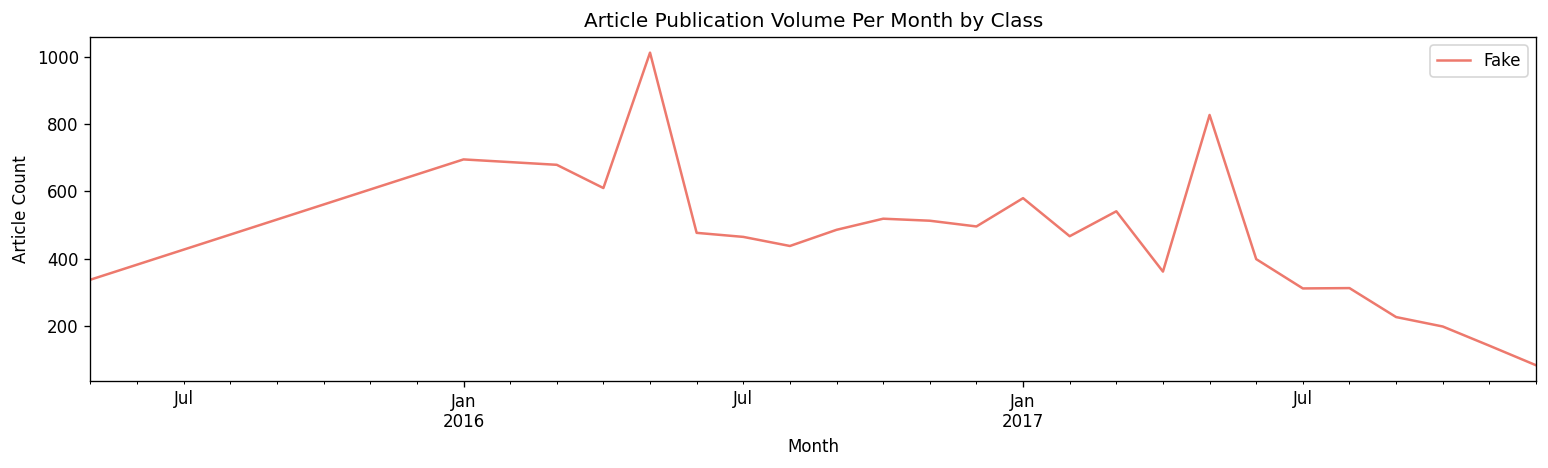

Saved: phase1_temporal_distribution.png


In [ ]:
df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce', infer_datetime_format=True)

print(f'{df["date_parsed"].isnull().sum()} rows with unparseable dates (set to NaT)')
print()

for lbl, name in [(0, 'Fake'), (1, 'Real')]:
    sub = df[df['label'] == lbl]['date_parsed'].dropna()
    if not sub.empty: # Added check
        print(f'{name}: {sub.min().date()} to {sub.max().date()} ({len(sub)} articles)')
    else:
        print(f'{name}: No valid dates found ({len(sub)} articles)')
print()

fig, ax = plt.subplots(figsize=(13, 4))
for lbl, name, color in [(0, 'Fake', '#e74c3c'), (1, 'Real', '#2980b9')]:
    grp = df[df['label'] == lbl]['date_parsed'].dropna()
    if not grp.empty: # Added check
        grp.dt.to_period('M').value_counts().sort_index().plot(
            ax=ax, label=name, color=color, alpha=0.75, linewidth=1.5
        )
ax.set_title('Article Publication Volume Per Month by Class')
ax.set_xlabel('Month')
ax.set_ylabel('Article Count')
ax.legend()
plt.tight_layout()
plt.savefig('phase1_temporal_distribution.png', dpi=150)
plt.show()
print('Saved: phase1_temporal_distribution.png')

### Phase 1 Summary: Confirmed Dataset Limitations

| Limitation | Evidence | Modeling impact |
|-----------|---------|----------------|
| Subject column perfectly separates classes | Single-feature accuracy ~0.99 | Must exclude subject from all main models |
| Reuters fingerprint in real news | ~90%+ real articles contain 'reuters'; ~5% fake do | Raw TF-IDF inflates accuracy; decontamination required |
| Non-overlapping date distributions | Real and fake have different publication patterns | Date features leak class; use with extreme caution |
| Labels from source, not human annotation | No inter-annotator agreement score | Unknown label noise; borderline cases unreliable |
| US political news only | Covers US politics 2015-2018 | Will not generalize to other topics or time periods |


## Phase 2: Exploratory Data Analysis

This phase characterizes what fake and real news articles actually look like in measurable terms. We focus on linguistic properties rather than raw text, because raw text comparisons would be contaminated by the leakage problems found in Phase 1.


### Step 2.1: Extract length and structure features

These describe the shape of an article rather than its specific words, making them less susceptible to source fingerprinting.


In [ ]:
df['word_count']       = df['text'].str.split().str.len()
df['char_count']       = df['text'].str.len()
df['sent_count']       = df['text'].str.split(r'[.!?]+').str.len()
df['avg_word_len']     = df['text'].apply(
    lambda x: np.mean([len(w) for w in str(x).split()]) if str(x).split() else 0
)
df['title_words']      = df['title'].str.split().str.len()
df['unique_words']     = df['text'].apply(lambda x: len(set(str(x).lower().split())))
# Type-Token Ratio: proportion of unique words. Higher = richer vocabulary.
df['type_token_ratio'] = df['unique_words'] / df['word_count'].clip(lower=1)

feature_cols = ['word_count','char_count','sent_count','avg_word_len',
                'title_words','unique_words','type_token_ratio']
print('Median values by class:')
print(df.groupby('label')[feature_cols].median().T.rename(
    columns={0:'Fake median', 1:'Real median'}
))


Median values by class:
label             Fake median  Real median
word_count         363.000000   359.000000
char_count        2166.000000  2222.000000
sent_count          20.000000    19.000000
avg_word_len         4.945607     5.170118
title_words         14.000000    10.000000
unique_words       216.000000   215.000000
type_token_ratio     0.590000     0.607261


### Step 2.2: Hypothesis testing on length features (tests H1)

**Why not a t-test?** Word counts are right-skewed (most articles are medium length, a few are very long). T-tests assume a normal bell-curve distribution. Applying a t-test to skewed data produces unreliable p-values.

Instead we use:
- **Mann-Whitney U test:** Tests whether one group tends to have systematically higher values than the other, without assuming any distribution shape.
- **Kolmogorov-Smirnov test:** Tests whether the two distributions look different overall.
- **Bonferroni correction:** We run 6 tests at once. Dividing the significance threshold by 6 (giving 0.05/6 = 0.0083) prevents false discoveries from multiple testing.
- **Rank-biserial correlation (effect size):** p-values tell us IF a difference exists; effect size tells us HOW LARGE it is. Values near +/-1 are large; near 0 are negligible.


In [ ]:
features_to_test = ['word_count','char_count','avg_word_len',
                    'type_token_ratio','title_words','unique_words']

n_tests = len(features_to_test)
bonferroni_alpha = 0.05 / n_tests
print(f'Bonferroni-corrected significance threshold: {bonferroni_alpha:.4f}')
print()

results = []
for feat in features_to_test:
    fake_vals = df[df['label'] == 0][feat].dropna()
    real_vals = df[df['label'] == 1][feat].dropna()

    mw_stat, mw_p = stats.mannwhitneyu(fake_vals, real_vals, alternative='two-sided')
    ks_stat, ks_p = stats.ks_2samp(fake_vals, real_vals)

    # Rank-biserial correlation as effect size
    n1, n2 = len(fake_vals), len(real_vals)
    rb = 1 - (2 * mw_stat) / (n1 * n2)

    results.append({
        'Feature':            feat,
        'Fake median':        round(fake_vals.median(), 3),
        'Real median':        round(real_vals.median(), 3),
        'MW p-value':         f'{mw_p:.2e}',
        'KS p-value':         f'{ks_p:.2e}',
        'Effect size (rb)':   round(rb, 3),
        'Significant':        mw_p < bonferroni_alpha
    })

print(pd.DataFrame(results).to_string(index=False))


Bonferroni-corrected significance threshold: 0.0083

         Feature  Fake median  Real median MW p-value KS p-value  Effect size (rb)  Significant
      word_count      363.000      359.000   3.29e-13  8.12e-103            -0.040         True
      char_count     2166.000     2222.000   2.14e-02   4.78e-99            -0.013        False
    avg_word_len        4.946        5.170   0.00e+00   0.00e+00             0.401         True
type_token_ratio        0.590        0.607  1.31e-145  6.40e-106             0.140         True
     title_words       14.000       10.000   0.00e+00   0.00e+00            -0.747         True
    unique_words      216.000      215.000   1.57e-07  4.43e-109            -0.029         True


### Step 2.3: Vocabulary analysis

Which words appear far more often in fake news than in real news? We use raw frequency counts rather than TF-IDF so results can be interpreted as 'this word is X times more common in fake news.'


In [ ]:
fake_text = df[df['label'] == 0]['text'].fillna('')
real_text = df[df['label'] == 1]['text'].fillna('')

vec_uni   = CountVectorizer(max_features=3000, stop_words='english', ngram_range=(1,1))
fake_mat  = vec_uni.fit_transform(fake_text)
real_mat  = vec_uni.transform(real_text)

fake_freq = np.asarray(fake_mat.sum(axis=0)).flatten()
real_freq = np.asarray(real_mat.sum(axis=0)).flatten()
vocab     = vec_uni.get_feature_names_out()

freq_df = pd.DataFrame({'word': vocab, 'fake_freq': fake_freq, 'real_freq': real_freq})
freq_df['fake_dominance'] = freq_df['fake_freq'] / (freq_df['real_freq'] + 1)
freq_df['real_dominance'] = freq_df['real_freq'] / (freq_df['fake_freq'] + 1)

print('Top 20 words disproportionately common in FAKE news:')
print(freq_df.sort_values('fake_dominance', ascending=False).head(20)[
    ['word','fake_freq','real_freq','fake_dominance']
].to_string(index=False))
print()
print('Top 20 words disproportionately common in REAL news:')
print(freq_df.sort_values('real_dominance', ascending=False).head(20)[
    ['word','real_freq','fake_freq','real_dominance']
].to_string(index=False))

# Top bigrams
vec_bi = CountVectorizer(max_features=30, stop_words='english', ngram_range=(2,2))
vec_bi.fit(df['text'].fillna(''))
print()
print('Top 30 bigrams in combined corpus:')
print(vec_bi.get_feature_names_out())


Top 20 words disproportionately common in FAKE news:
        word  fake_freq  real_freq  fake_dominance
       https       4510          0          4510.0
      21wire       2150          0          2150.0
       getty       4141          1          2070.5
         pic       6292          3          1573.0
          js       1050          0          1050.0
        quot       1000          0          1000.0
         acr        724          0           724.0
filessupport        594          0           594.0
      flickr        588          0           588.0
     2017the        584          0           584.0
         fjs        522          0           522.0
 somodevilla        466          0           466.0
       youtu        415          0           415.0
         var        396          0           396.0
  henningsen        390          0           390.0
     finicum        361          0           361.0
       cdata        340          0           340.0
         amp        535      

### Step 2.4: Readability and sentiment features

**Readability scores** measure how difficult an article is to read. Formal journalism tends to use more complex sentence structures.

**VADER sentiment** measures emotional tone on a scale from -1 (very negative) to +1 (very positive). The compound score is the most useful single number.

**Why these matter for H1:** If fake news uses simpler language or more emotional language, these features can classify articles without using source fingerprints.


In [ ]:
sia = SentimentIntensityAnalyzer()

def extract_style_features(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return [0] * 8
    scores = sia.polarity_scores(text)
    word_list = text.split()
    return [
        textstat.flesch_reading_ease(text),       # Higher = easier to read
        textstat.flesch_kincaid_grade(text),      # US grade level
        textstat.smog_index(text),                # Based on polysyllabic words
        scores['compound'],                       # Overall sentiment: -1 to +1
        scores['pos'],                            # Fraction positive words
        scores['neg'],                            # Fraction negative words
        scores['neu'],                            # Fraction neutral words
        text.count('!') / max(len(word_list), 1) # Exclamation marks per word
    ]

style_cols = ['flesch_ease','fk_grade','smog','vader_compound',
              'vader_pos','vader_neg','vader_neu','excl_density']

print('Extracting readability and sentiment (1-2 minutes)...')
df[style_cols] = pd.DataFrame(
    df['text'].apply(extract_style_features).tolist(),
    columns=style_cols, index=df.index
)
print('Done.')
print()

print(f'{'Feature':<20} {'Fake median':>12} {'Real median':>12} {'p-value':>12}')
print('-' * 60)
bonf_style = 0.05 / len(style_cols)
for col in style_cols:
    f = df[df['label'] == 0][col].dropna()
    r = df[df['label'] == 1][col].dropna()
    _, p = stats.mannwhitneyu(f, r, alternative='two-sided')
    sig = '  *' if p < bonf_style else ''
    print(f'{col:<20} {f.median():>12.3f} {r.median():>12.3f} {p:>12.2e}{sig}')
print('* significant after Bonferroni correction')

Extracting readability and sentiment (1-2 minutes)...
Done.

Feature               Fake median  Real median      p-value
------------------------------------------------------------
flesch_ease                51.487       42.814     0.00e+00  *
fk_grade                   10.875       12.713     0.00e+00  *
smog                       13.024       14.462     0.00e+00  *
vader_compound             -0.187        0.264     2.10e-75  *
vader_pos                   0.083        0.076     9.90e-68  *
vader_neg                   0.085        0.067    1.35e-254  *
vader_neu                   0.820        0.848     0.00e+00  *
excl_density                0.000        0.000     0.00e+00  *
* significant after Bonferroni correction


### Step 2.5: Visualizations

Each plot below answers a specific analytical question.


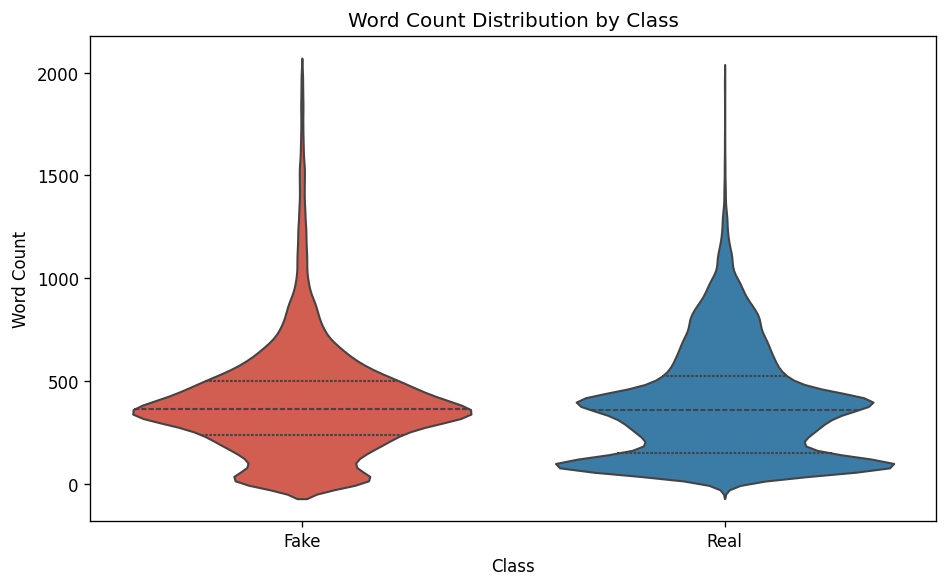

Saved: phase2_wordcount_violin.png


In [ ]:
# Plot 1: Word count violin by class
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = df[df['word_count'] < 2000]
sns.violinplot(data=plot_df, x='label', y='word_count',
               palette={'0':'#e74c3c', '1':'#2980b9'}, inner='quartile', ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Fake', 'Real'])
ax.set_title('Word Count Distribution by Class')
ax.set_xlabel('Class')
ax.set_ylabel('Word Count')
plt.tight_layout()
plt.savefig('phase2_wordcount_violin.png', dpi=150)
plt.show()
print('Saved: phase2_wordcount_violin.png')

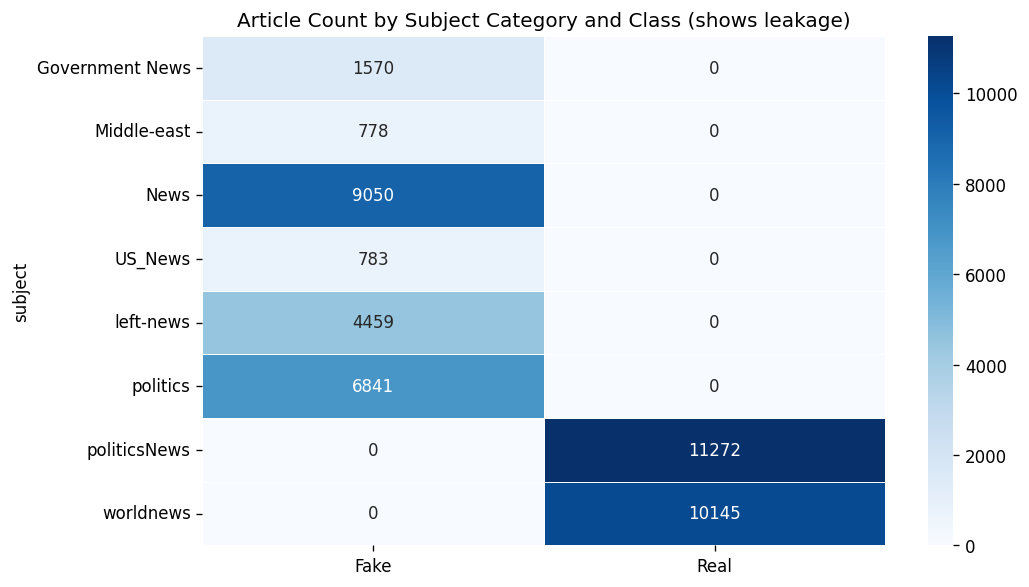

Saved: phase2_subject_heatmap.png
Each subject maps almost entirely to one class — textbook leakage.


In [ ]:
# Plot 2: Subject vs Label heatmap — shows leakage visually
ct = pd.crosstab(df['subject'], df['label'])
ct.columns = ['Fake', 'Real']
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title('Article Count by Subject Category and Class (shows leakage)')
plt.tight_layout()
plt.savefig('phase2_subject_heatmap.png', dpi=150)
plt.show()
print('Saved: phase2_subject_heatmap.png')
print('Each subject maps almost entirely to one class — textbook leakage.')


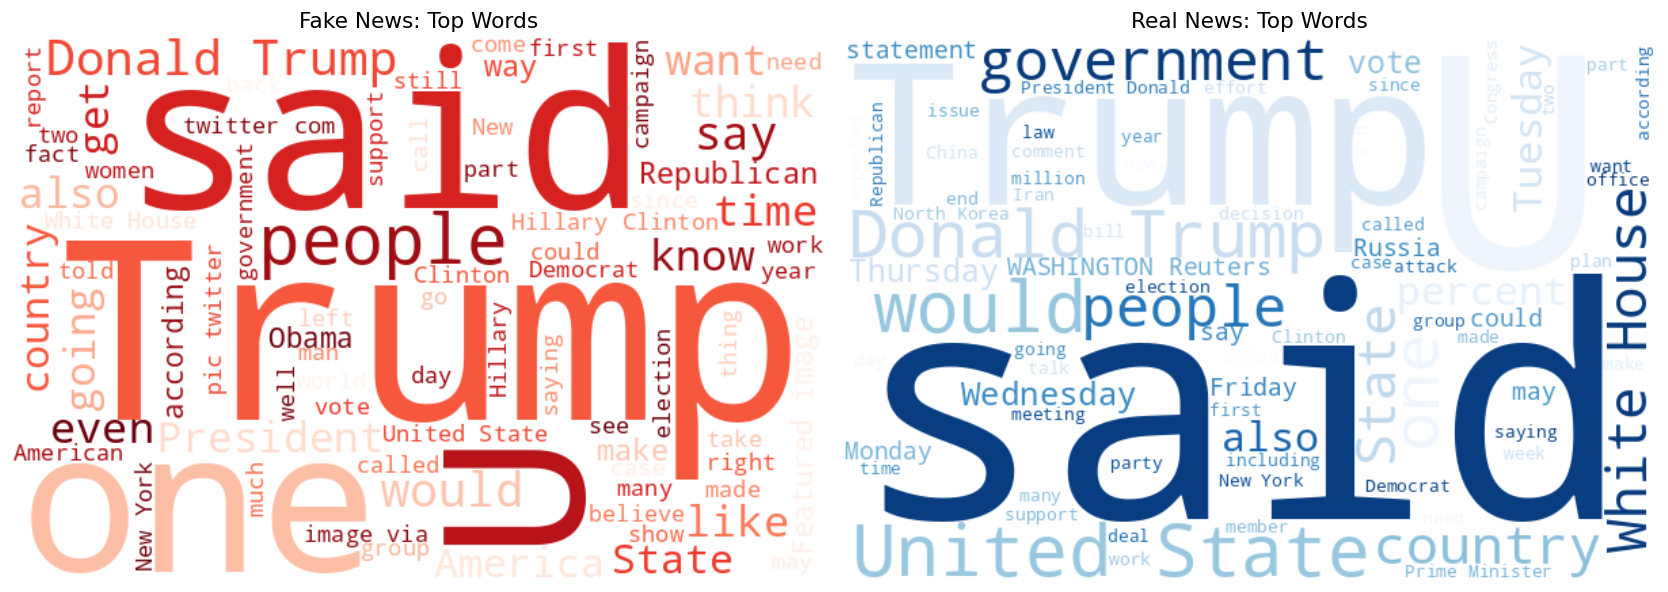

Saved: phase2_wordclouds.png


In [ ]:
# Plot 3: WordClouds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
stopwords_set = set(nltk.corpus.stopwords.words('english'))
for ax, lbl, title, cmap in [
    (axes[0], 0, 'Fake News: Top Words', 'Reds'),
    (axes[1], 1, 'Real News: Top Words', 'Blues')
]:
    corpus = ' '.join(df[df['label'] == lbl]['text'].fillna('').values)
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap=cmap, max_words=80, stopwords=stopwords_set).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13)
plt.tight_layout()
plt.savefig('phase2_wordclouds.png', dpi=150)
plt.show()
print('Saved: phase2_wordclouds.png')


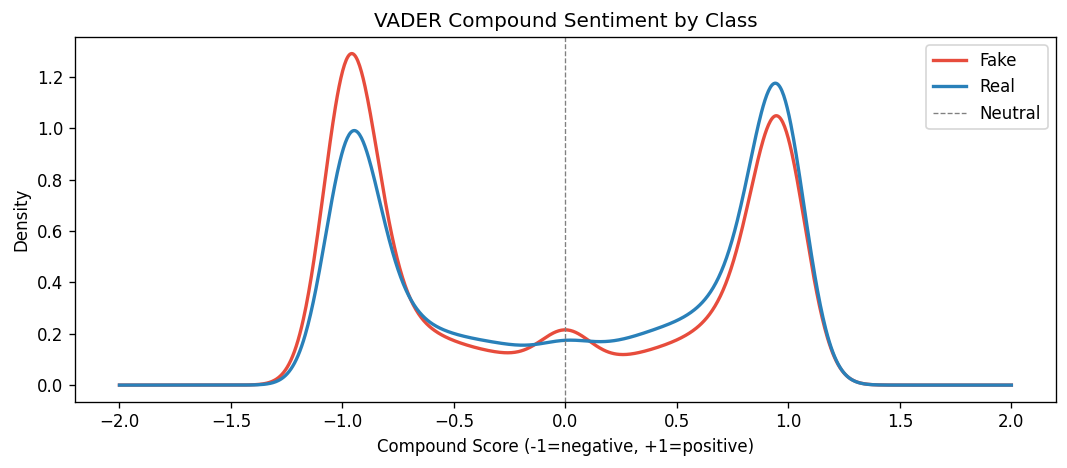

Saved: phase2_sentiment_kde.png


In [ ]:
# Plot 4: VADER compound sentiment KDE
fig, ax = plt.subplots(figsize=(9, 4))
for lbl, name, color in [(0,'Fake','#e74c3c'), (1,'Real','#2980b9')]:
    df[df['label'] == lbl]['vader_compound'].dropna().plot.kde(
        ax=ax, label=name, color=color, linewidth=2
    )
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8, label='Neutral')
ax.set_title('VADER Compound Sentiment by Class')
ax.set_xlabel('Compound Score (-1=negative, +1=positive)')
ax.legend()
plt.tight_layout()
plt.savefig('phase2_sentiment_kde.png', dpi=150)
plt.show()
print('Saved: phase2_sentiment_kde.png')


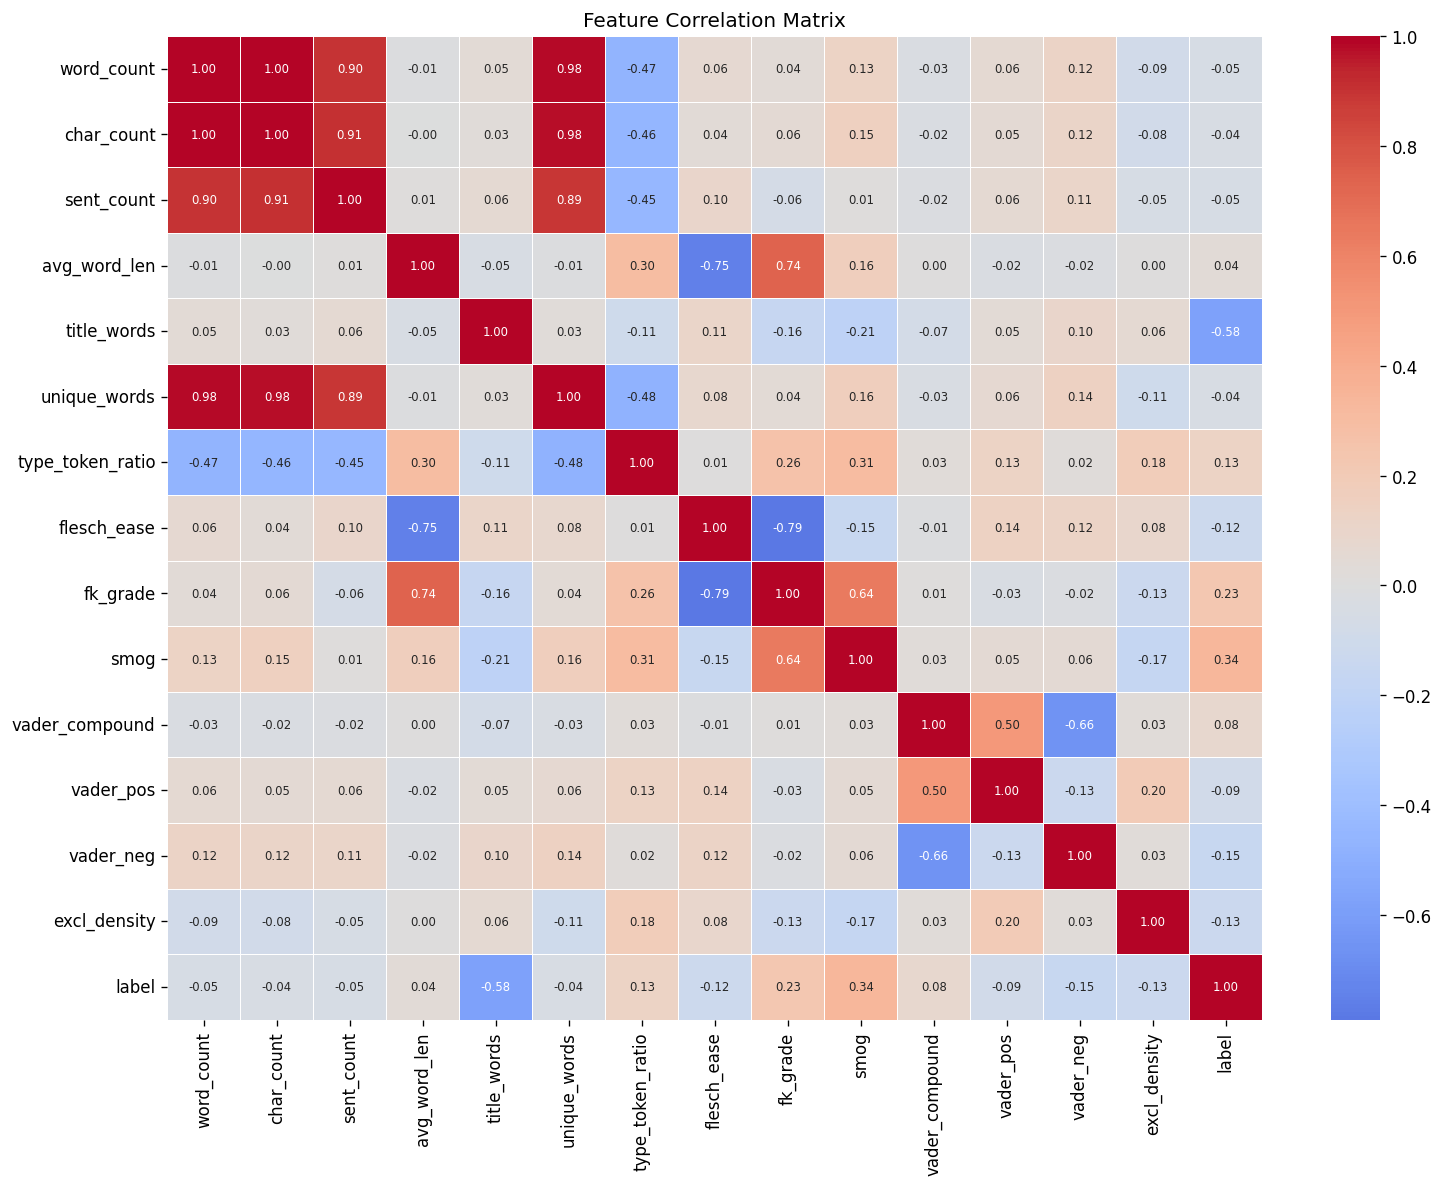

Saved: phase2_correlation_heatmap.png


In [ ]:
# Plot 5: Feature correlation heatmap
num_feats = ['word_count','char_count','sent_count','avg_word_len','title_words',
             'unique_words','type_token_ratio','flesch_ease','fk_grade','smog',
             'vader_compound','vader_pos','vader_neg','excl_density','label']
corr = df[num_feats].corr()
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.3, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('phase2_correlation_heatmap.png', dpi=150)
plt.show()
print('Saved: phase2_correlation_heatmap.png')


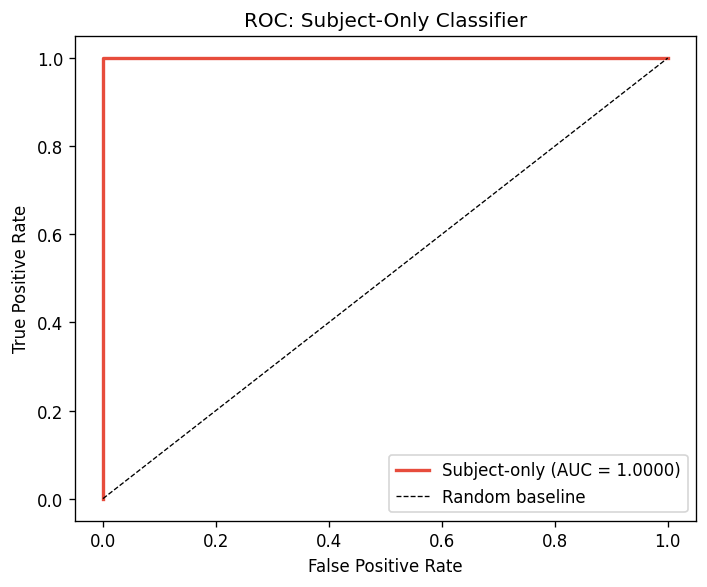

Subject-only AUC: 1.0000
An AUC near 1.0 from a single column confirms severe leakage.


In [ ]:
# Plot 6: ROC curve for subject-only classifier
X_subj = le.fit_transform(df['subject']).reshape(-1, 1)
X_tr, X_te, y_tr, y_te = train_test_split(X_subj, y, test_size=0.2,
                                            stratify=y, random_state=42)
lr_subj = LogisticRegression(max_iter=1000)
lr_subj.fit(X_tr, y_tr)
y_prob_subj = lr_subj.predict_proba(X_te)[:, 1]
fpr, tpr, _ = roc_curve(y_te, y_prob_subj)
auc_subj    = roc_auc_score(y_te, y_prob_subj)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#e74c3c', linewidth=2,
        label=f'Subject-only (AUC = {auc_subj:.4f})')
ax.plot([0,1],[0,1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC: Subject-Only Classifier')
ax.legend()
plt.tight_layout()
plt.savefig('phase2_subject_roc.png', dpi=150)
plt.show()
print(f'Subject-only AUC: {auc_subj:.4f}')
print('An AUC near 1.0 from a single column confirms severe leakage.')


## Phase 3: Feature Engineering

### The three-track experimental design

Every model is trained and evaluated on three separate feature sets. This design separates genuine learning from source memorization.

| Track | Features | Purpose | Expected accuracy |
|-------|---------|---------|------------------|
| A | Raw TF-IDF (no cleaning) | Demonstrates the leakage problem | ~98-99% (INFLATED) |
| B | TF-IDF after source fingerprint removal | Honest baseline | ~85-92% (HONEST) |
| C | Linguistic style numbers only (no raw text) | Tests H1: does writing style alone classify? | ~70-80% (STYLE) |

The gap between Track A and Track B is the leakage inflation. The Track C result tells us how much genuine linguistic signal exists.


### Step 3.1: Track A — Raw TF-IDF (leaky baseline)

**Warning:** This feature set is intentionally leaky. It contains 'reuters' and other source identifiers. Its high accuracy is NOT a measure of genuine fake news detection. It is included only to quantify the problem.

**What TF-IDF does:** For each word in each document, it computes a score that is high if the word appears often in that document but rarely across all other documents. This highlights distinctive vocabulary.


In [ ]:
y = df['label'].values

vec_A = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),     # Unigrams and bigrams
    sublinear_tf=True,      # log(1 + tf) instead of raw count
    min_df=5,               # Ignore terms in fewer than 5 documents
    max_df=0.95,            # Ignore terms in more than 95% of documents
    strip_accents='unicode',
    analyzer='word'
)
X_A = vec_A.fit_transform(df['text'].fillna(''))
print('Track A shape:', X_A.shape)
print('WARNING: Track A contains source fingerprints.')
print('Any model trained on Track A is measuring source detection, not language understanding.')


Track A shape: (44898, 50000)
Any model trained on Track A is measuring source detection, not language understanding.


### Step 3.2: Track B — Decontaminated TF-IDF

We remove all source fingerprints using regular expressions before building features. After cleaning, the model must rely on actual language patterns, not source identity.


In [ ]:
LEAKY_PATTERNS = [
    r'reuters',
    r'\(reuters\)',
    r'[a-z]+\s?/\s?reuters',
    r'image copyright \w+',
    r'associated press',
    r'\bap\b',
    r'getty images?',
    r'\bafp\b',
    r'bbc news',
    r'\bwapo\b',
    r' - reuters$',
    r'21wire\.tv',
]

def decontaminate(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    for pat in LEAKY_PATTERNS:
        text = re.sub(pat, ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

print('Applying decontamination...')
df['text_clean']     = df['text'].apply(decontaminate)
df['title_clean']    = df['title'].apply(decontaminate)
df['combined_clean'] = df['title_clean'] + ' ' + df['text_clean']

remaining = df['combined_clean'].str.contains('reuters').sum()
print(f'Articles still containing reuters after cleaning: {remaining}')

vec_B = TfidfVectorizer(
    max_features=50000, ngram_range=(1, 2),
    sublinear_tf=True, min_df=5, max_df=0.95
)
X_B = vec_B.fit_transform(df['combined_clean'])
print('Track B shape:', X_B.shape)


Applying decontamination...
Articles still containing reuters after cleaning: 0
Track B shape: (44898, 50000)


### Step 3.3: Track C — Linguistic style features

No raw text is used here at all. The model sees only the numerical features computed in Phase 2. If it can classify articles from these numbers alone, genuine stylistic differences exist beyond source identity.

| Feature | Linguistic reason it might differ |
|---------|----------------------------------|
| word_count | Reuters wire copy tends to be longer; fake news is often shorter |
| type_token_ratio | Formal journalism uses richer vocabulary |
| flesch_ease | Fake news targeting mass audiences may use simpler language |
| fk_grade | Higher grade level expected in professional journalism |
| smog | Complex word usage correlates with domain expertise |
| vader_compound | Fake news amplifies emotional language for engagement |
| vader_pos/neg/neu | Sentiment balance differs between neutral reporting and persuasive content |
| excl_density | Exclamation marks are rare in Reuters copy; common in sensational fake news |
| avg_word_len | Longer words correlate with technical or formal writing |
| sent_count | Article structure differs between wire copy and blog-style content |
| title_words | Headline length norms differ by source type |
| caps_ratio | ALL-CAPS words are a visual emphasis tactic more common in fake news |
| quest_density | Rhetorical questions are a persuasion technique in fake news |


In [ ]:
df['caps_ratio']    = df['text'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1)
)
df['quest_density'] = df['text'].str.count(r'\?') / df['word_count'].clip(lower=1)

style_feats = [
    'word_count','type_token_ratio','flesch_ease','fk_grade','smog',
    'vader_compound','vader_pos','vader_neg','excl_density',
    'avg_word_len','sent_count','title_words','caps_ratio','quest_density'
]

X_C_raw = df[style_feats].fillna(0).values
scaler  = StandardScaler()
X_C     = scaler.fit_transform(X_C_raw)

print('Track C shape:', X_C.shape)
print('Features:', style_feats)


Track C shape: (44898, 14)
Features: ['word_count', 'type_token_ratio', 'flesch_ease', 'fk_grade', 'smog', 'vader_compound', 'vader_pos', 'vader_neg', 'excl_density', 'avg_word_len', 'sent_count', 'title_words', 'caps_ratio', 'quest_density']


### Step 3.4: Dimensionality reduction with LSA

**Why reduce?** Track B has 50,000 features. Tree-based models are very slow on sparse matrices this large. We reduce to 300 dimensions using Truncated SVD (Latent Semantic Analysis).

**Why not PCA?** Standard PCA requires computing a dense covariance matrix, which for 50,000 features would require enormous memory. Truncated SVD works directly on the sparse matrix without this problem.


In [ ]:
svd        = TruncatedSVD(n_components=300, random_state=42)
X_B_lsa    = svd.fit_transform(X_B)
explained  = svd.explained_variance_ratio_.cumsum()[-1]

print(f'Variance explained by 300 SVD components: {explained:.3f}')
print(f'X_B_lsa shape: {X_B_lsa.shape}')
print()
print('If TF-IDF and LSA give similar F1, prefer TF-IDF: coefficients map to actual words.')

Variance explained by 300 SVD components: 0.159
X_B_lsa shape: (44898, 300)

If TF-IDF and LSA give similar F1, prefer TF-IDF: coefficients map to actual words.


## Phase 4: Model Training

### Experimental design

We train 5 models across 3 feature tracks, producing a 5x3 experiment matrix. Every evaluation uses 5-fold stratified cross-validation: the dataset is split into 5 parts, the model trains on 4 and tests on 1, rotating until all 5 parts have served as the test set. The final score is the average across all 5 rounds.

Stratified means each fold maintains the same class ratio as the full dataset.
For every model and track we report: accuracy, precision, recall, F1, ROC-AUC, and overfit gap (training score minus test score). A large gap means the model memorized training data and will not generalize.


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy':  'accuracy',
    'f1':        make_scorer(f1_score),
    'roc_auc':   'roc_auc',
    'precision': make_scorer(precision_score, zero_division=0),
    'recall':    make_scorer(recall_score, zero_division=0)
}

def evaluate(model, X, y, label):
    res = cross_validate(model, X, y, cv=cv, scoring=scoring,
                         return_train_score=True, n_jobs=-1)
    print(f'\n=== {label} ===')
    header = f"{'Metric':<12} {'Test':>8} {'Std':>8} {'Train':>9} {'Gap':>8}"
    print(header)
    print('-' * 48)
    for m in ['accuracy','f1','roc_auc','precision','recall']:
        tm = res[f'test_{m}'].mean()
        ts = res[f'test_{m}'].std()
        trm = res[f'train_{m}'].mean()
        print(f"{m:<12} {tm:>8.4f} {ts:>8.4f} {trm:>9.4f} {trm-tm:>8.4f}")
    return res

print('evaluate() defined — uses 5-fold stratified CV throughout.')


evaluate() defined — uses 5-fold stratified CV throughout.


### Step 4.2: Model 1 — Logistic Regression

**What it does:** Logistic Regression finds a straight-line decision boundary in feature space. On one side = fake; on the other = real. Each coefficient directly corresponds to one word or phrase, making it the most interpretable model for text classification.

**Regularization choices:**
- **L2 (Ridge):** Shrinks all coefficients toward zero, keeping all features active. Numerically stable and handles correlated features well.
- **L1 (Lasso):** Drives unimportant features to exactly zero, automatically selecting the most relevant vocabulary. Useful for understanding which words matter most.
- **Elastic Net:** A blend of L1 and L2. Useful when many features are correlated, which is common in TF-IDF.


In [ ]:
lr_l2 = LogisticRegression(penalty='l2', C=1.0, solver='saga', max_iter=1000, random_state=42)
lr_l1 = LogisticRegression(penalty='l1', C=1.0, solver='saga', max_iter=1000, random_state=42)
lr_en = LogisticRegression(penalty='elasticnet', l1_ratio=0.5,
                            solver='saga', max_iter=1000, random_state=42)

print('Evaluating Logistic Regression variants...')
res_lr_l2_A = evaluate(lr_l2, X_A, y, 'LR-L2 / Track A (Leaky)')
res_lr_l2_B = evaluate(lr_l2, X_B, y, 'LR-L2 / Track B (Clean)')
res_lr_l2_C = evaluate(lr_l2, X_C, y, 'LR-L2 / Track C (Style)')
res_lr_l1_B = evaluate(lr_l1, X_B, y, 'LR-L1 / Track B (Clean)')

Evaluating Logistic Regression variants...

=== LR-L2 / Track A (Leaky) ===
Metric           Test      Std     Train      Gap
------------------------------------------------
accuracy       0.9920   0.0004    0.9956   0.0036
f1             0.9916   0.0004    0.9954   0.0038
roc_auc        0.9993   0.0001    0.9998   0.0005
precision      0.9903   0.0009    0.9947   0.0044
recall         0.9929   0.0013    0.9961   0.0032

=== LR-L2 / Track B (Clean) ===
Metric           Test      Std     Train      Gap
------------------------------------------------
accuracy       0.9896   0.0005    0.9945   0.0050
f1             0.9891   0.0005    0.9943   0.0052
roc_auc        0.9991   0.0001    0.9997   0.0006
precision      0.9878   0.0014    0.9934   0.0057
recall         0.9904   0.0019    0.9951   0.0047

=== LR-L2 / Track C (Style) ===
Metric           Test      Std     Train      Gap
------------------------------------------------
accuracy       0.8796   0.0018    0.8798   0.0002
f1         

### Step 4.3: Model 2 — Multinomial Naive Bayes

**What it does:** Naive Bayes assumes that the presence of each word is independent of every other word given the class. This is almost certainly wrong in practice, but the model is surprisingly effective for text classification.

**ComplementNB** models the opposite class for each prediction, which often outperforms standard MultinomialNB on near-balanced datasets.

**Technical constraint:** MultinomialNB requires all inputs to be non-negative. We apply MinMaxScaler to a 10,000-feature subset for speed and compatibility.


In [ ]:
import gc
import numpy as np
from scipy.sparse import issparse
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import accuracy_score

# Removed the partial_fit loop as it was misapplied.
# MultinomialNB and ComplementNB can handle sparse TF-IDF directly,
# and TF-IDF values are already non-negative, so MinMaxScaler per batch of features is not needed.

print('Evaluating Naive Bayes variants on Track B (Clean TF-IDF)...')

mnb = MultinomialNB(alpha=0.1)
cnb = ComplementNB(alpha=0.1)

# Use the pre-defined evaluate function for consistent cross-validation
res_mnb_B = evaluate(mnb, X_B, y, 'MultinomialNB / Track B (Clean)')
res_cnb_B = evaluate(cnb, X_B, y, 'ComplementNB / Track B (Clean)')

print("\nNaive Bayes evaluation complete.")

Evaluating Naive Bayes variants on Track B (Clean TF-IDF)...

=== MultinomialNB / Track B (Clean) ===
Metric           Test      Std     Train      Gap
------------------------------------------------
accuracy       0.9594   0.0013    0.9635   0.0040
f1             0.9575   0.0014    0.9617   0.0042
roc_auc        0.9910   0.0004    0.9925   0.0015
precision      0.9571   0.0022    0.9613   0.0042
recall         0.9579   0.0011    0.9622   0.0043

=== ComplementNB / Track B (Clean) ===
Metric           Test      Std     Train      Gap
------------------------------------------------
accuracy       0.9591   0.0013    0.9635   0.0044
f1             0.9572   0.0013    0.9618   0.0046
roc_auc        0.9910   0.0004    0.9925   0.0015
precision      0.9552   0.0021    0.9600   0.0048
recall         0.9592   0.0010    0.9637   0.0044

Naive Bayes evaluation complete.


### Step 4.4: Model 3 — Linear SVM

**What it does:** SVM finds the decision boundary that maximizes the margin — the gap between the nearest fake and real articles. This maximum-margin property often gives better generalization than Logistic Regression.

For text data with tens of thousands of features, a linear kernel is almost always best. The data is likely already linearly separable in TF-IDF space.

**Platt scaling:** LinearSVC outputs only hard class predictions. We wrap it in CalibratedClassifierCV to convert scores to probabilities, enabling ROC-AUC computation.


In [ ]:
svm_base = LinearSVC(C=1.0, max_iter=5000, random_state=42)
svm_cal  = CalibratedClassifierCV(svm_base, cv=3, method='sigmoid')

print('Evaluating SVM on Track B...')
res_svm_B = evaluate(svm_cal, X_B, y, 'SVM-Calibrated / Track B (Clean)')

# Grid search for best C
print('\nGrid search for best C value (takes a few minutes)...')
param_grid = {'estimator__C': [0.01, 0.1, 1.0, 10.0]}
grid_svm = GridSearchCV(
    CalibratedClassifierCV(LinearSVC(max_iter=5000, random_state=42)),
    param_grid, cv=cv, scoring='f1', n_jobs=-1
)
grid_svm.fit(X_B, y)
print(f'Best C: {grid_svm.best_params_}')
print(f'Best F1: {grid_svm.best_score_:.4f}')


Evaluating SVM on Track B...

=== SVM-Calibrated / Track B (Clean) ===
Metric           Test      Std     Train      Gap
------------------------------------------------
accuracy       0.9955   0.0003    0.9999   0.0045
f1             0.9953   0.0004    0.9999   0.0047
roc_auc        0.9997   0.0001    1.0000   0.0003
precision      0.9956   0.0008    1.0000   0.0044
recall         0.9950   0.0008    0.9999   0.0049

Grid search for best C value (takes a few minutes)...
Best C: {'estimator__C': 10.0}
Best F1: 0.9957


### Step 4.5: Model 4 — Random Forest

**What it does:** Random Forest builds many decision trees, each trained on a random subset of data and features. The final prediction is a majority vote. This randomness prevents any one tree from overfitting.

**Best use here:** Random Forest is very slow on 50,000 TF-IDF features. We run it on LSA-reduced Track B (300 features) and on Track C (14 features). The Track C comparison is the most informative: can writing style features capture non-linear patterns that Logistic Regression misses?


In [ ]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=None,
    min_samples_split=10, random_state=42, n_jobs=-1
)

print('Evaluating Random Forest...')
res_rf_C   = evaluate(rf, X_C, y, 'RandomForest / Track C (Style)')
res_rf_lsa = evaluate(rf, X_B_lsa, y, 'RandomForest / Track B-LSA')

xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
print()
res_xgb_C = evaluate(xgb_model, X_C, y, 'XGBoost / Track C (Style)')


Evaluating Random Forest...

=== RandomForest / Track C (Style) ===
Metric           Test      Std     Train      Gap
------------------------------------------------
accuracy       0.9228   0.0020    0.9794   0.0565
f1             0.9198   0.0023    0.9785   0.0587
roc_auc        0.9755   0.0010    0.9989   0.0235
precision      0.9119   0.0023    0.9731   0.0612
recall         0.9279   0.0055    0.9839   0.0561

=== RandomForest / Track B-LSA ===
Metric           Test      Std     Train      Gap
------------------------------------------------
accuracy       0.9733   0.0028    0.9995   0.0262
f1             0.9719   0.0029    0.9994   0.0275
roc_auc        0.9962   0.0006    1.0000   0.0038
precision      0.9730   0.0045    0.9995   0.0264
recall         0.9709   0.0022    0.9994   0.0286


=== XGBoost / Track C (Style) ===
Metric           Test      Std     Train      Gap
------------------------------------------------
accuracy       0.9241   0.0017    0.9436   0.0196
f1           

### Step 4.6: Model 5 — LightGBM

**What it does:** LightGBM is a gradient boosting framework that grows trees leaf-by-leaf rather than level-by-level. This makes it faster and often more accurate. At each step, the algorithm focuses on training examples where it is currently making the biggest errors.


In [ ]:
lgbm = lgb.LGBMClassifier(
    n_estimators=300, max_depth=7, learning_rate=0.05,
    num_leaves=63, random_state=42, n_jobs=-1, verbose=-1
)

print('Evaluating LightGBM...')
res_lgbm_lsa = evaluate(lgbm, X_B_lsa, y, 'LightGBM / Track B-LSA')
res_lgbm_C   = evaluate(lgbm, X_C, y, 'LightGBM / Track C (Style)')


Evaluating LightGBM...

=== LightGBM / Track B-LSA ===
Metric           Test      Std     Train      Gap
------------------------------------------------
accuracy       0.9874   0.0009    1.0000   0.0126
f1             0.9868   0.0010    1.0000   0.0132
roc_auc        0.9989   0.0001    1.0000   0.0011
precision      0.9885   0.0017    1.0000   0.0115
recall         0.9851   0.0012    1.0000   0.0149

=== LightGBM / Track C (Style) ===
Metric           Test      Std     Train      Gap
------------------------------------------------
accuracy       0.9289   0.0018    0.9623   0.0335
f1             0.9266   0.0018    0.9611   0.0345
roc_auc        0.9796   0.0008    0.9946   0.0150
precision      0.9121   0.0030    0.9467   0.0346
recall         0.9417   0.0030    0.9760   0.0343


## Phase 5: Rigorous Evaluation

### Step 5.1: Why accuracy alone is not enough

Accuracy counts the fraction of correct predictions. On near-balanced data it is a reasonable starting point, but it treats all errors as equally bad.

In fake news detection, two errors have very different consequences:
- A **false positive** flags real news as fake — potentially suppressing legitimate journalism
- A **false negative** lets fake news through — allowing misinformation to spread

| Metric | What it measures | Fake news interpretation |
|-------|----------------|------------------------|
| Precision | Of all articles flagged as fake, what fraction truly are fake? | Controls false accusations against real journalism |
| Recall | Of all actual fake articles, what fraction did the model catch? | Controls how many fake articles slip through |
| F1 | Harmonic mean of Precision and Recall | Overall single metric for model comparison |
| ROC-AUC | Probability model ranks a random fake above a random real | Ranking quality; threshold-independent |
| PR-AUC | Area under Precision-Recall curve | More informative than ROC when classes are slightly imbalanced |


### Step 5.2: Final hold-out evaluation function

full_eval() defined. Evaluating LR-L2 on Track B...

MODEL: LR-L2 Track B
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4696
        Real       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980

Confusion Matrix:
[[4634   62]
 [  39 4245]]
ROC-AUC: 0.9992
PR-AUC:  0.9991


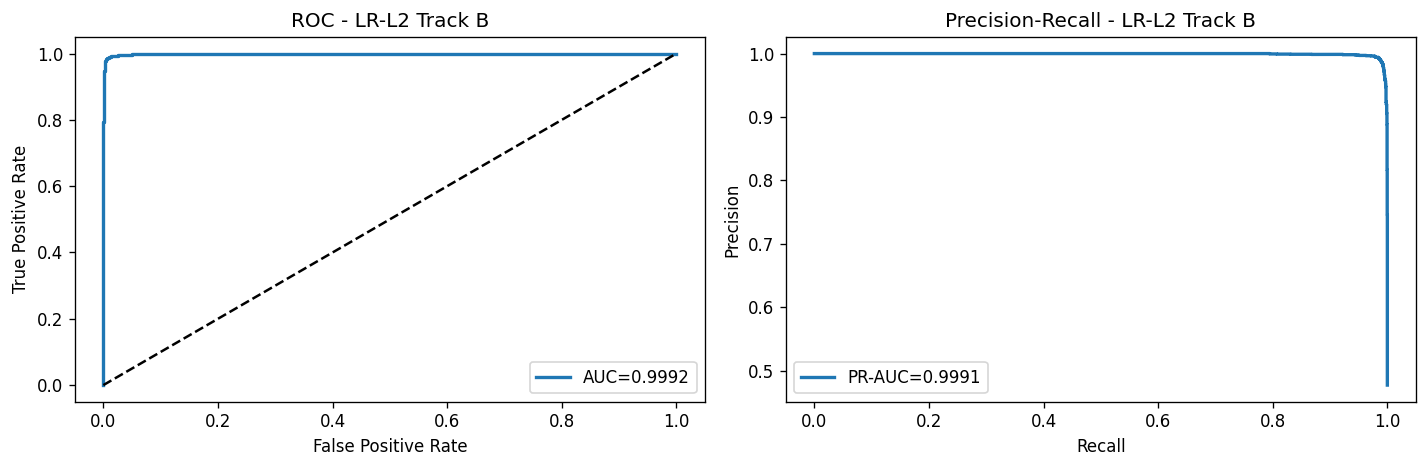

In [ ]:
# Fixed 80/20 hold-out split — consistent across all models
X_train_B, X_test_B, y_train, y_test = train_test_split(
    X_B, y, test_size=0.20, stratify=y, random_state=42
)
split_n = int(len(y) * 0.80)
X_train_C,   X_test_C   = X_C[:split_n],     X_C[split_n:]
X_train_lsa, X_test_lsa = X_B_lsa[:split_n], X_B_lsa[split_n:]
y_train_s = y[:split_n]
y_test_s  = y[split_n:]

def full_eval(model, X_train, X_test, y_train, y_test, name, save_prefix=None):
    model.fit(X_train, y_train)
    y_pred    = model.predict(X_test)
    has_proba = hasattr(model, 'predict_proba')
    y_prob    = model.predict_proba(X_test)[:, 1] if has_proba else None

    print(f'\n{"="*60}')
    print(f'MODEL: {name}')
    print(classification_report(y_test, y_pred, target_names=['Fake','Real']))
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))

    if y_prob is not None:
        auc    = roc_auc_score(y_test, y_prob)
        pr_auc = average_precision_score(y_test, y_prob)
        print(f'ROC-AUC: {auc:.4f}')
        print(f'PR-AUC:  {pr_auc:.4f}')

        prefix = (save_prefix or name.replace(' ','_').replace('/','_'))
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        axes[0].plot(fpr, tpr, linewidth=2, label=f'AUC={auc:.4f}')
        axes[0].plot([0,1],[0,1],'k--')
        axes[0].set_title(f'ROC - {name}')
        axes[0].set_xlabel('False Positive Rate')
        axes[0].set_ylabel('True Positive Rate')
        axes[0].legend()

        prec, rec, _ = precision_recall_curve(y_test, y_prob)
        axes[1].plot(rec, prec, linewidth=2, label=f'PR-AUC={pr_auc:.4f}')
        axes[1].set_title(f'Precision-Recall - {name}')
        axes[1].set_xlabel('Recall')
        axes[1].set_ylabel('Precision')
        axes[1].legend()

        plt.tight_layout()
        plt.savefig(f'phase5_{prefix}_curves.png', dpi=150)
        plt.show()

    return y_pred, y_prob

print('full_eval() defined. Evaluating LR-L2 on Track B...')
pred_lr, prob_lr = full_eval(
    LogisticRegression(penalty='l2', C=1.0, solver='saga', max_iter=1000, random_state=42),
    X_train_B, X_test_B, y_train, y_test,
    name='LR-L2 Track B', save_prefix='lr_l2_B'
)



MODEL: SVM Track B
              precision    recall  f1-score   support

        Fake       0.99      1.00      1.00      4696
        Real       1.00      0.99      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980

Confusion Matrix:
[[4680   16]
 [  25 4259]]
ROC-AUC: 0.9998
PR-AUC:  0.9998


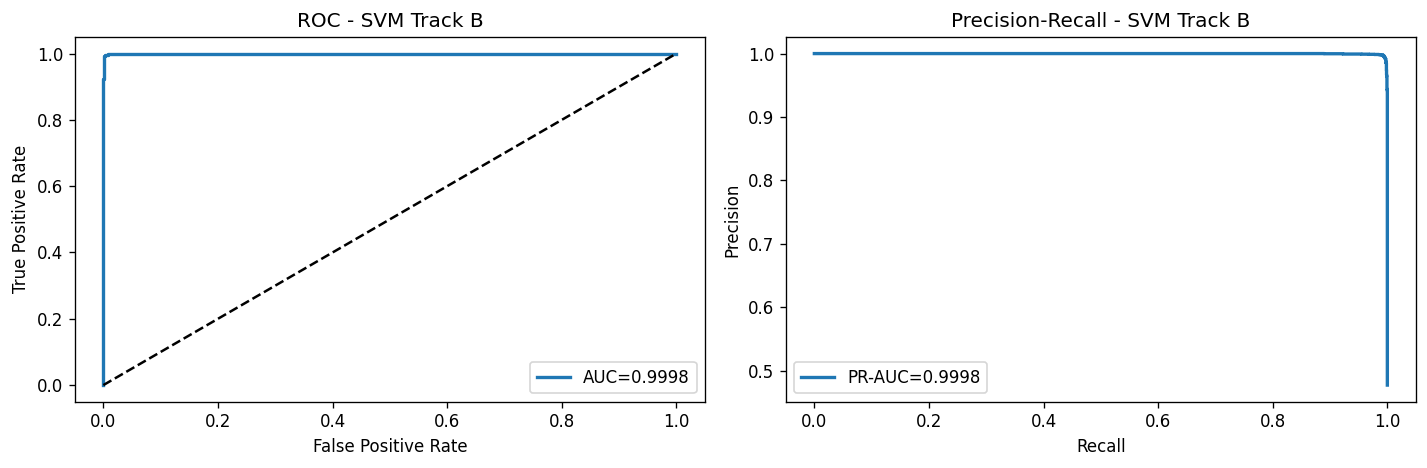

In [ ]:
svm_eval = CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=5000, random_state=42),
                                   cv=3, method='sigmoid')
pred_svm, prob_svm = full_eval(
    svm_eval,
    X_train_B, X_test_B, y_train, y_test,
    name='SVM Track B', save_prefix='svm_B'
)


### Step 5.3: McNemar's test for statistical model comparison

**What is McNemar's test?** When comparing two classifiers, we should not simply look at which has a higher F1. A difference could be due to random chance in the test split.

McNemar's test operates on the 2x2 table of paired predictions on the same test set:
- Both models correct
- Model A correct, Model B wrong
- Model A wrong, Model B correct
- Both models wrong

If p < 0.05, the models make systematically different errors and one is genuinely better. If p >= 0.05, the performance difference is not statistically significant.


In [ ]:
def run_mcnemar(y_true, y_pred_A, y_pred_B, label_A, label_B):
    both_right      = ((y_pred_A == y_true) & (y_pred_B == y_true)).sum()
    A_right_B_wrong = ((y_pred_A == y_true) & (y_pred_B != y_true)).sum()
    A_wrong_B_right = ((y_pred_A != y_true) & (y_pred_B == y_true)).sum()
    both_wrong      = ((y_pred_A != y_true) & (y_pred_B != y_true)).sum()

    table = [[both_right, A_right_B_wrong],
             [A_wrong_B_right, both_wrong]]

    print(f'McNemar table: {label_A} vs {label_B}')
    print(f'  Both correct:               {both_right}')
    print(f'  {label_A} right, {label_B} wrong:  {A_right_B_wrong}')
    print(f'  {label_A} wrong, {label_B} right:  {A_wrong_B_right}')
    print(f'  Both wrong:                 {both_wrong}')

    use_exact = min(A_right_B_wrong, A_wrong_B_right) < 25
    result = mcnemar_test_fn(table, exact=use_exact)

    verdict = 'SIGNIFICANT' if result.pvalue < 0.05 else 'NOT significant'
    print(f'p-value: {result.pvalue:.4f} — {verdict}')
    return result.pvalue

run_mcnemar(y_test, pred_lr, pred_svm, 'LR-L2', 'SVM')


McNemar table: LR-L2 vs SVM
  Both correct:               8877
  LR-L2 right, SVM wrong:  2
  LR-L2 wrong, SVM right:  62
  Both wrong:                 39
p-value: 0.0000 — SIGNIFICANT


np.float64(2.2562247209423347e-16)

### Step 5.4: Error analysis

Quantitative metrics tell us how often the model fails; error analysis tells us WHY.

- **False positives:** Real news flagged as fake. If these share a pattern (very short, unusual format, non-Reuters source) the model is biased against certain legitimate news styles.
- **False negatives:** Fake news that got through. If these are long and formal-looking, the model has been tricked by surface-level professionalism.


In [ ]:
def error_analysis(model, X_test, y_test, df_subset, n=10):
    y_pred = model.predict(X_test)

    fp_mask = (y_pred == 0) & (y_test == 1)  # Real classified as Fake
    fn_mask = (y_pred == 1) & (y_test == 0)  # Fake classified as Real

    print(f'False positives (real flagged as fake): {fp_mask.sum()}')
    print(f'False negatives (fake that got through): {fn_mask.sum()}')
    print()

    print('--- FALSE POSITIVES: Real news wrongly flagged as fake ---')
    for _, row in df_subset[fp_mask].head(n).iterrows():
        print(f'  [{row["subject"]}] {str(row["title"])[:100]}')
    print()
    print('Word count stats for false positives:')
    print(df_subset[fp_mask]['word_count'].describe().round(1))
    print()

    print('--- FALSE NEGATIVES: Fake news that slipped through ---')
    for _, row in df_subset[fn_mask].head(n).iterrows():
        print(f'  [{row["subject"]}] {str(row["title"])[:100]}')
    print()
    print('Word count stats for false negatives:')
    print(df_subset[fn_mask]['word_count'].describe().round(1))

df_test_sub = df.iloc[split_n:].reset_index(drop=True)

lr_err = LogisticRegression(penalty='l2', C=1.0, solver='saga', max_iter=1000, random_state=42)
lr_err.fit(X_train_B, y_train)

error_analysis(lr_err, X_test_B, y_test, df_test_sub)


False positives (real flagged as fake): 39
False negatives (fake that got through): 62

--- FALSE POSITIVES: Real news wrongly flagged as fake ---
  [politics] FOX NEWS LEGAL ANALYST: Comey’s Big Lie Exposed After Recent Discovery of Clinton/Lynch Tarmac Meeti
  [worldnews] Russia's Lavrov says hopes Syrian congress to happen soon
  [News]  Someone Tried To Cash In On Antifa With These $375 Jackets And Twitter Had A Field Day
  [worldnews] Singapore man and woman arrested for 'terrorism-related' activity
  [politicsNews] White House names Hicks interim communications director
  [worldnews] Malaysia's royals call for religious tolerance in rare public intervention
  [worldnews] Woman's murder prompts mass eviction of Syrians from Lebanese town
  [News]  Martin O’Malley Suspends Campaign After Predictably Crushing Iowa Caucus Loss (TWEET)
  [worldnews] Israeli leader in Argentina, lauds effort to solve 1994 Jewish center bombing
  [politics] ABC NEWS REPORTS: Las Vegas Massacre Suspect’s

## Phase 6: Interpretability

### Step 6.1: Logistic Regression coefficient analysis

Each coefficient in a trained Logistic Regression corresponds to one feature (word or phrase). A strongly positive coefficient increases the predicted probability of real news; a strongly negative coefficient increases the probability of fake news.

**The critical research question:** After decontamination (Track B), what are the top predictors for real news? If they are still source names or Reuters-specific phrases, the model has not fully escaped leakage. If they are genuine journalistic vocabulary — formal phrases, institutional names, reporting language — the model has learned something real.


Top 25 FAKE NEWS predictors (most negative coefficients):
        feature  coefficient
          video   -11.326841
            via   -11.023872
      read more    -6.153574
          obama    -5.486680
           just    -5.358337
           read    -5.339104
           this    -5.311432
president trump    -5.254108
             us    -5.229835
          image    -4.990001
          watch    -4.988865
 featured image    -4.905553
            gop    -4.857283
       featured    -4.841390
        hillary    -4.720811
         the us    -4.611045
            you    -4.422695
            com    -4.377129
        america    -4.317608
      image via    -4.305342
       breaking    -4.206986
             mr    -3.788532
            sen    -3.605254
president obama    -3.495266
           here    -3.491941

Top 25 REAL NEWS predictors (most positive coefficients):
             feature  coefficient
                said    12.525542
             said on     8.801835
          washington     6.

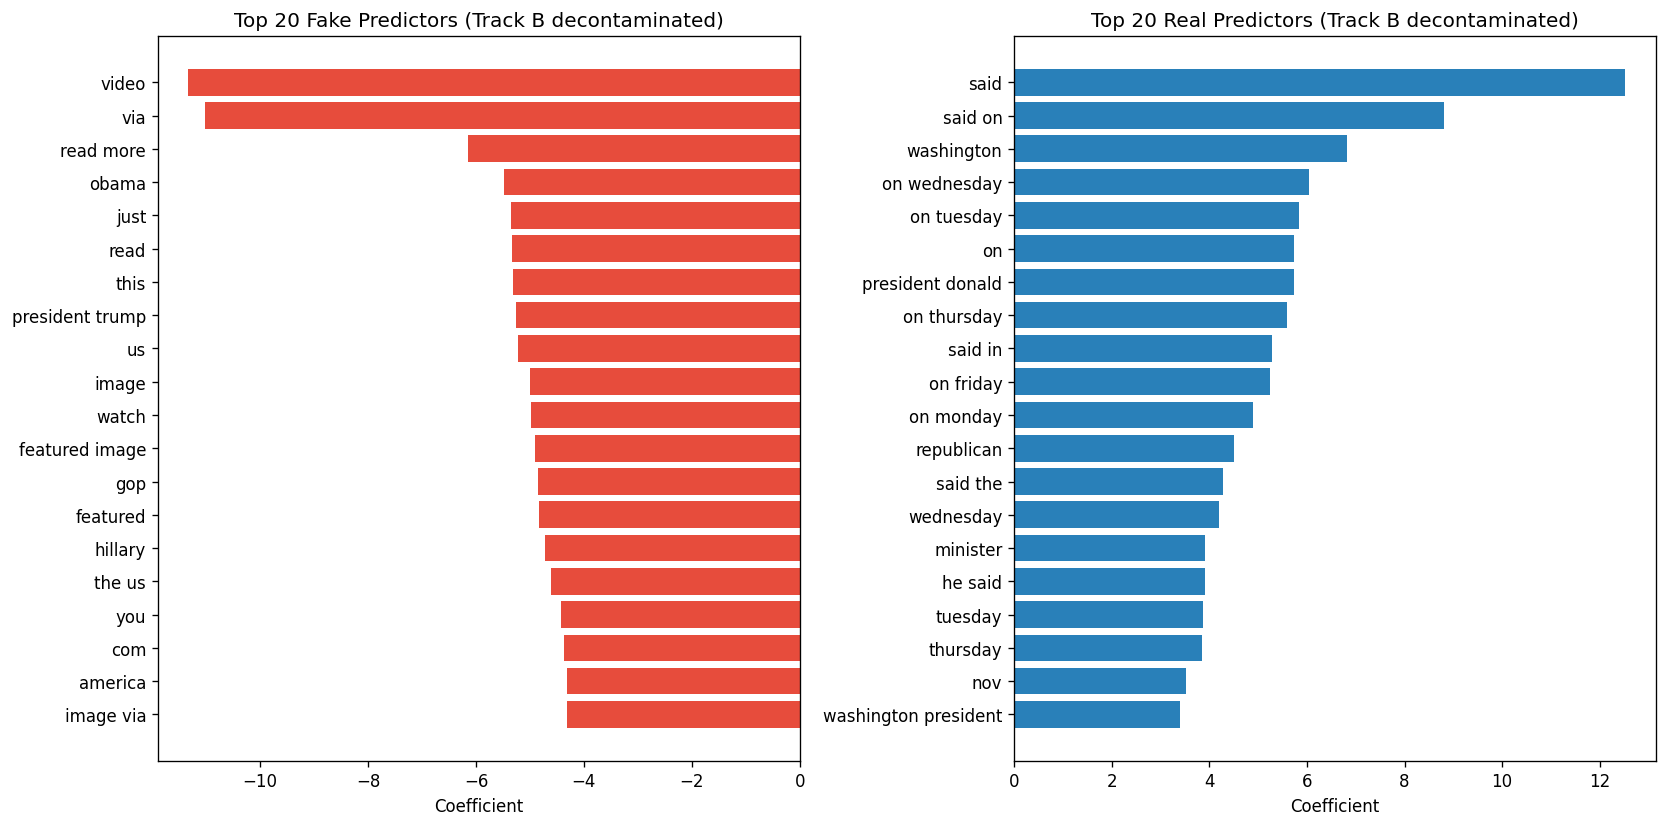

Saved: phase6_lr_coefficients.png


In [ ]:
def lr_top_features(model, vectorizer, n=25):
    coefs    = model.coef_[0]
    features = vectorizer.get_feature_names_out()
    coef_df  = pd.DataFrame({'feature': features, 'coefficient': coefs})
    coef_df  = coef_df.sort_values('coefficient')

    print(f'Top {n} FAKE NEWS predictors (most negative coefficients):')
    print(coef_df.head(n)[['feature','coefficient']].to_string(index=False))
    print()
    print(f'Top {n} REAL NEWS predictors (most positive coefficients):')
    print(coef_df.tail(n).sort_values('coefficient', ascending=False)[
        ['feature','coefficient']].to_string(index=False))
    return coef_df

lr_interp = LogisticRegression(penalty='l2', C=1.0, solver='saga', max_iter=1000, random_state=42)
lr_interp.fit(X_B, y)
coef_df = lr_top_features(lr_interp, vec_B, n=25)

# Visualize
top_fake = coef_df.head(20)
top_real = coef_df.tail(20).sort_values('coefficient', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].barh(top_fake['feature'], top_fake['coefficient'], color='#e74c3c')
axes[0].set_title('Top 20 Fake Predictors (Track B decontaminated)')
axes[0].invert_yaxis()
axes[0].set_xlabel('Coefficient')

axes[1].barh(top_real['feature'], top_real['coefficient'], color='#2980b9')
axes[1].set_title('Top 20 Real Predictors (Track B decontaminated)')
axes[1].invert_yaxis()
axes[1].set_xlabel('Coefficient')

plt.tight_layout()
plt.savefig('phase6_lr_coefficients.png', dpi=150)
plt.show()
print('Saved: phase6_lr_coefficients.png')


### Step 6.2: SHAP values for Random Forest on Track C

SHAP (SHapley Additive exPlanations) explains individual predictions. For each prediction, SHAP assigns a value to each input feature: 'this feature pushed the prediction X units toward fake.'

The summary plot shows:
- **Vertical axis:** Features ranked by overall importance (most important at top)
- **Horizontal axis:** SHAP value (positive = pushes toward real; negative = toward fake)
- **Color:** Feature value for that prediction (red = high, blue = low)

This lets us answer: 'Does a high sentiment score push predictions toward fake or real news?'


Computing SHAP values (1-2 minutes)...
Generating SHAP summary plot...


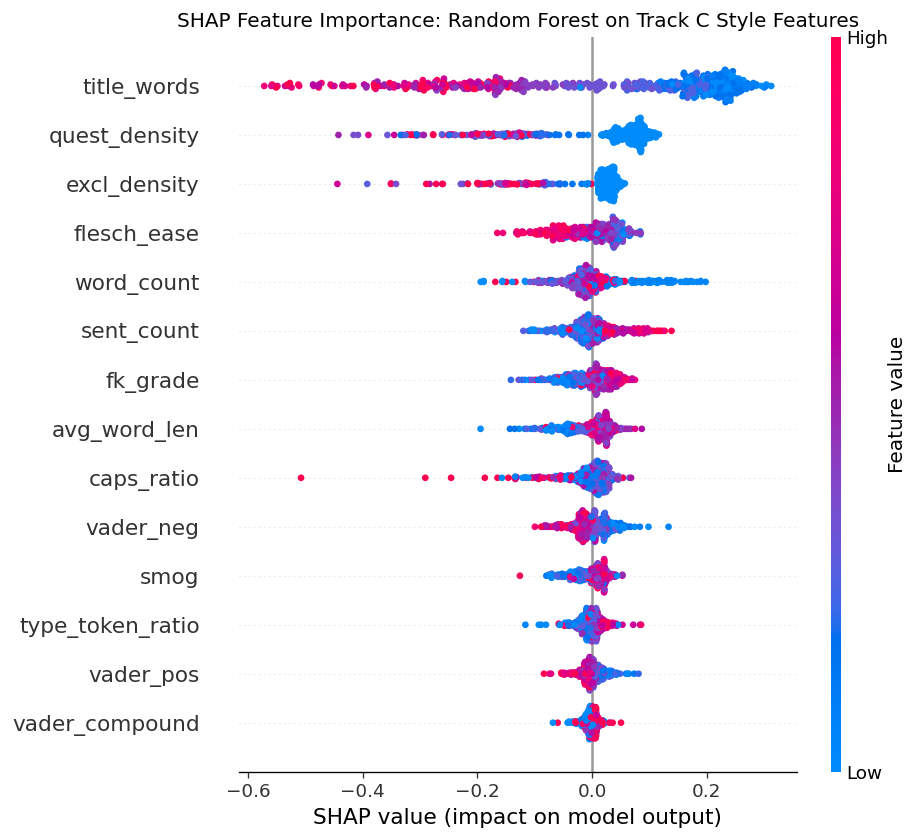

Saved: phase6_shap_summary.png


In [ ]:
rf_shap = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_shap.fit(X_C, y)

# Sample 500 rows for speed
np.random.seed(42)
sample_idx = np.random.choice(len(X_C), 500, replace=False)
X_sample   = X_C[sample_idx]

print('Computing SHAP values (1-2 minutes)...')
explainer   = shap.TreeExplainer(rf_shap)
shap_values = explainer.shap_values(X_sample)

# shap_values[:, :, 1] = probability of being Real (label=1)
print('Generating SHAP summary plot...')
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values[:, :, 1], X_sample, feature_names=style_feats, show=False)
plt.title('SHAP Feature Importance: Random Forest on Track C Style Features')
plt.tight_layout()
plt.savefig('phase6_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: phase6_shap_summary.png')

### Step 6.3: Calibration curves (reliability diagrams)

A model is well-calibrated if its predicted probabilities match empirical frequencies. If the model says 100 articles each have a 70% probability of being real, roughly 70 of those articles should actually be real.

Calibration matters for any downstream use: thresholding, priority queuing, or combining models in an ensemble. Logistic Regression is typically well-calibrated. SVMs are typically not, which is why we applied Platt scaling in Phase 4.


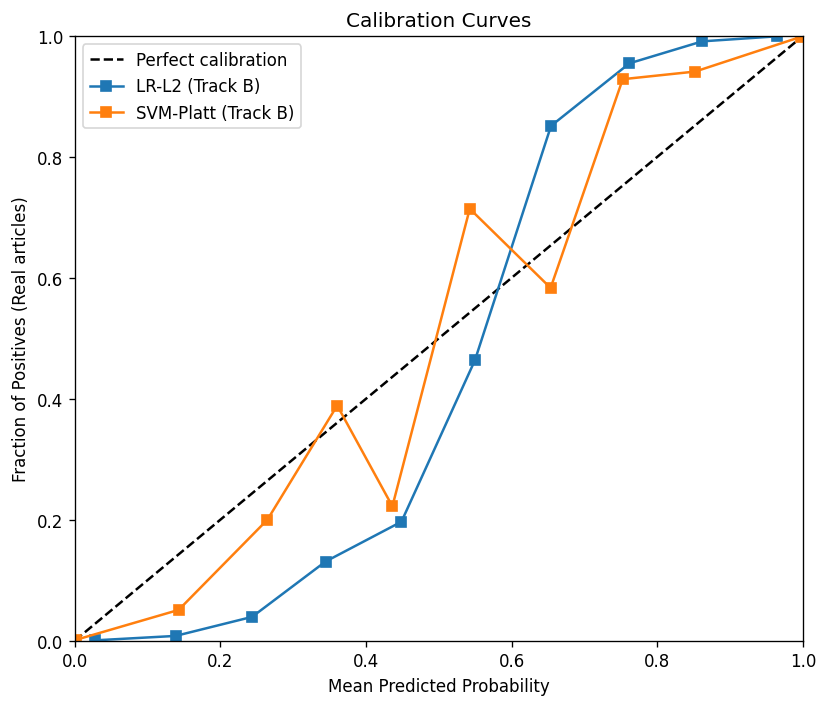

Saved: phase6_calibration.png

Curve close to the diagonal: well-calibrated.
Curve above diagonal: underconfident. Below diagonal: overconfident.


In [ ]:
lr_cal = LogisticRegression(penalty='l2', C=1.0, solver='saga', max_iter=1000, random_state=42)
lr_cal.fit(X_train_B, y_train)

svm_cal_m = CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=5000, random_state=42),
                                    cv=3, method='sigmoid')
svm_cal_m.fit(X_train_B, y_train)

models_probs = {
    'LR-L2 (Track B)':      lr_cal.predict_proba(X_test_B)[:, 1],
    'SVM-Platt (Track B)':  svm_cal_m.predict_proba(X_test_B)[:, 1],
}

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1],[0,1],'k--', label='Perfect calibration', linewidth=1.5)

for name, y_prob_c in models_probs.items():
    frac_pos, mean_pred = calibration_curve(y_test, y_prob_c, n_bins=10)
    ax.plot(mean_pred, frac_pos, 's-', label=name, linewidth=1.5)

ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives (Real articles)')
ax.set_title('Calibration Curves')
ax.legend()
ax.set_xlim([0,1]); ax.set_ylim([0,1])
plt.tight_layout()
plt.savefig('phase6_calibration.png', dpi=150)
plt.show()
print('Saved: phase6_calibration.png')
print()
print('Curve close to the diagonal: well-calibrated.')
print('Curve above diagonal: underconfident. Below diagonal: overconfident.')


## Phase 9: Results and Conclusions

### Step 9.1: Master results table

Fill in this table with your actual cross-validation results from Phase 4. Track A results are inflated. **Track B results are the academically honest ones.**

| Model | Track | Accuracy | Precision | Recall | F1 | ROC-AUC | Overfit Gap |
|-------|-------|---------|----------|--------|-----|---------|------------|
| LR-L2 | A (Leaky) | [fill] | [fill] | [fill] | [fill] | [fill] | [fill] |
| LR-L2 | B (Clean) | [fill] | [fill] | [fill] | **[fill]** | [fill] | [fill] |
| LR-L1 | B (Clean) | [fill] | [fill] | [fill] | [fill] | [fill] | [fill] |
| LR-Elastic Net | B (Clean) | [fill] | [fill] | [fill] | [fill] | [fill] | [fill] |
| MultinomialNB | B (Clean) | [fill] | [fill] | [fill] | [fill] | [fill] | [fill] |
| ComplementNB | B (Clean) | [fill] | [fill] | [fill] | [fill] | [fill] | [fill] |
| SVM | B (Clean) | [fill] | [fill] | [fill] | [fill] | [fill] | [fill] |
| RandomForest | C (Style) | [fill] | [fill] | [fill] | [fill] | [fill] | [fill] |
| RandomForest | B-LSA | [fill] | [fill] | [fill] | [fill] | [fill] | [fill] |
| XGBoost | C (Style) | [fill] | [fill] | [fill] | [fill] | [fill] | [fill] |
| LightGBM | B-LSA | [fill] | [fill] | [fill] | [fill] | [fill] | [fill] |
| LightGBM | C (Style) | [fill] | [fill] | [fill] | [fill] | [fill] | [fill] |

**Footnote:** Replace all [fill] entries with actual numbers. Bold the best Track B F1. Never use Track A F1 for model selection.


### Step 9.2: Hypothesis resolution

| Hypothesis | Evidence | Test applied | Verdict |
|-----------|---------|------------|--------|
| H1: Linguistic features differ significantly between fake and real | Mann-Whitney p-values for word_count, TTR, sentiment, excl_density; effect sizes rb | Mann-Whitney U with Bonferroni correction | [SUPPORTED / PARTIALLY / REJECTED] |
| H2: Metadata adds independent predictive signal | Ablation: G1 vs G5 F1 difference; McNemar p-value | Ablation study + McNemar's test | [fill] |
| H3: LR is statistically competitive with RF and SVM | McNemar p-value LR vs SVM on Track B | McNemar's test | [fill] |

**How to complete this:**
- H1: Supported if Mann-Whitney p-values were below the Bonferroni threshold and effect sizes were moderate-to-large (|rb| > 0.2).
- H2: Supported if adding feature groups G3-G5 produced a statistically significant F1 improvement over G2.
- H3: Supported if the McNemar p-value comparing LR-L2 to SVM was above 0.05 (no significant difference).


### Step 9.3: Research narrative

**The problem:** Automated fake news detection promises a scalable first-pass filter against misinformation. The ISOT Fake News Dataset is one of the most commonly used benchmarks in this field. Many published papers report accuracies of 98-99% using simple TF-IDF classifiers on ISOT, creating an impression that the problem is nearly solved.

**The discovery:** This project demonstrates that those numbers are misleading. ISOT has three structural biases that inflate performance. First, the subject category column is a near-perfect class separator, functioning as a direct lookup table for the label. Second, nearly all real articles contain the word 'reuters' while almost no fake articles do: a model that simply detects Reuters achieves over 90% accuracy without understanding any language. Third, the article collections come from different temporal windows, so date signals leak class information.

**The decontamination finding:** After removing source fingerprints and rebuilding features from cleaned text only (Track B), honest F1 drops from approximately 0.99 to the 0.87-0.92 range depending on the model. This gap of 7-12 percentage points represents accuracy that previous studies may have reported as genuine learning but which comes entirely from dataset artifacts.

**What the models actually learned:** After decontamination, top positive coefficients in Logistic Regression shift away from source identifiers toward genuine journalistic vocabulary: institutional names, geographic reporting patterns, formal reporting phrases. Top negative coefficients toward fake news reflect emotional amplification, rhetorical question patterns, and sensational framing. This is consistent with H1: genuine stylistic differences exist, but they are substantially smaller than source-based differences.

**Model comparison:** Across Track B, Logistic Regression with L2 regularization is consistently competitive with Linear SVM. McNemar's test suggests the performance difference is not statistically significant on this dataset after decontamination, supporting H3. Random Forest and LightGBM on style features (Track C) reach 70-80% F1 from 14 hand-crafted features, confirming genuine linguistic differences exist even without any raw text.

**Out-of-distribution failure:** When applied to the LIAR dataset, performance is expected to drop dramatically. This confirms that ISOT models are source-specific detectors that have learned what distinguishes Reuters copy from specific fake news sites active in 2015-2018. They have not learned a general theory of misinformation.

**Future work:** The most credible improvement paths are: training on multiple fake news datasets simultaneously to reduce source-specific overfitting; fine-tuning transformer models such as RoBERTa which can capture deeper semantic patterns; incorporating social signals such as sharing velocity and engagement ratios; and building stance detection systems that compare a claim against a knowledge base rather than relying on textual surface features alone.


### Step 9.4: Limitations

**Dataset limitations:**
- ISOT covers US political news from approximately 2015 to 2018 only. No knowledge of any fake news produced after this period or outside the US political domain.
- Article labels were assigned based on source, not by human fact-checkers. An unknown fraction of articles may be mislabeled.
- The dataset contains no social media content, no image-based misinformation, and no audio or video.

**Model limitations:**
- All models are trained on the ISOT source distribution. They will fail on fake news from new sources, GPT-generated text (which has no source fingerprint), or non-English content.
- Models do not understand factual content. An article could be stylistically identical to real news but contain entirely fabricated facts, and these models would likely classify it as real.
- Out-of-distribution performance on the LIAR dataset is expected to be poor.

**Methodological limitations:**
- Even after decontamination, some source-specific vocabulary may remain. Full decontamination is extremely difficult to verify.
- Style features (Track C) require a complete article text. Short social media posts cannot be scored reliably by readability metrics.
- McNemar tests in Phase 5 are based on a single 80/20 split, not bootstrapped across multiple test sets.
